# Growth Scenario Curve Generator

This notebook generates S-curve growth multipliers for a segment.

**Output**: `curves.parquet` with columns `[timestamp, index, value]`

**Usage**:
1. Configure the parameters below
2. Run all cells
3. Verify the output plot
4. The curves.parquet file is written to this folder

In [1]:
# ============================================================
# CONFIGURATION - Edit these values
# ============================================================

# Segment name (for labeling only)
SEGMENT = "services"  # Change this for each segment

# Time range
START_YEAR = 2025
END_YEAR = 2050
RESOLUTION = "1h"  # Hourly resolution

# S-curve parameters
MIDPOINT_YEAR = 2037  # When 50% of the transition has occurred
STEEPNESS = "10y"     # 90% of transition happens within this many years

# Growth scenario values
# Each entry is: (index, end_multiplier, label)
# - index: The scenario parameter index (0 = baseline, not stored)
# - end_multiplier: Final value in 2050 relative to 2025 (1.0 = no change)
#   Examples: 1.15 = +15% growth, 0.85 = -15% decline
# - label: Human-readable label

SCENARIOS = [
    # Negative growth (decline)
    (1, 0.85, "Low (-15%)"),
    (2, 0.90, "Medium-Low (-10%)"),
    (3, 0.95, "Slight Decline (-5%)"),
    # Positive growth
    (4, 1.05, "Slight Growth (+5%)"),
    (5, 1.10, "Medium-High (+10%)"),
    (6, 1.15, "High (+15%)"),
]

# Note: Index 0 is always baseline (no file needed, API uses base data)
print(f"Segment: {SEGMENT}")
print(f"Period: {START_YEAR}-{END_YEAR}")
print(f"S-curve midpoint: {MIDPOINT_YEAR}")
print(f"Scenarios: {len(SCENARIOS)}")
for idx, mult, label in SCENARIOS:
    print(f"  Index {idx}: {label} (end value = {mult})")

Segment: services
Period: 2025-2050
S-curve midpoint: 2037
Scenarios: 6
  Index 1: Low (-15%) (end value = 0.85)
  Index 2: Medium-Low (-10%) (end value = 0.9)
  Index 3: Slight Decline (-5%) (end value = 0.95)
  Index 4: Slight Growth (+5%) (end value = 1.05)
  Index 5: Medium-High (+10%) (end value = 1.1)
  Index 6: High (+15%) (end value = 1.15)


In [2]:
# Setup
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Add generator library to path
NOTEBOOK_DIR = Path.cwd()
GENERATOR_PATH = NOTEBOOK_DIR.parent.parent.parent  # input/scenarios/{segment}_growth -> generator
sys.path.insert(0, str(GENERATOR_PATH.parent))

from generator.library.curves import generate_s_curve

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Generator path: {GENERATOR_PATH}")

Notebook directory: /home/viktor/code/behovskartan/generator/input/scenarios/services_growth
Generator path: /home/viktor/code/behovskartan/generator


In [3]:
# Generate S-curves for each scenario
print(f"Generating {len(SCENARIOS)} S-curves...")

all_curves = []

for idx, end_multiplier, label in SCENARIOS:
    # Generate S-curve from 1.0 (base) to end_multiplier
    curve_df = generate_s_curve(
        curve_id=f"{SEGMENT}_growth_{idx}",
        start_year=START_YEAR,
        end_year=END_YEAR,
        y0=1.0,                    # Start at 1.0 (no change)
        y1=end_multiplier,         # End at target multiplier
        resolution=RESOLUTION,
        midpoint=f"{MIDPOINT_YEAR}-01-01",
        steepness=STEEPNESS,
    )
    
    # Add index column and keep only needed columns
    curve_df["index"] = idx
    all_curves.append(curve_df[["timestamp", "index", "value"]])
    
    # Show summary
    print(f"  Index {idx} ({label}): {curve_df['value'].iloc[0]:.4f} -> {curve_df['value'].iloc[-1]:.4f}")

# Combine all curves
result_df = pd.concat(all_curves, ignore_index=True)
print(f"\nTotal rows: {len(result_df):,}")
print(f"Unique indices: {sorted(result_df['index'].unique())}")

Generating 6 S-curves...
  Index 1 (Low (-15%)): 0.9999 -> 0.8500
  Index 2 (Medium-Low (-10%)): 0.9999 -> 0.9000
  Index 3 (Slight Decline (-5%)): 1.0000 -> 0.9500
  Index 4 (Slight Growth (+5%)): 1.0000 -> 1.0500
  Index 5 (Medium-High (+10%)): 1.0001 -> 1.1000
  Index 6 (High (+15%)): 1.0001 -> 1.1500

Total rows: 1,367,424
Unique indices: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


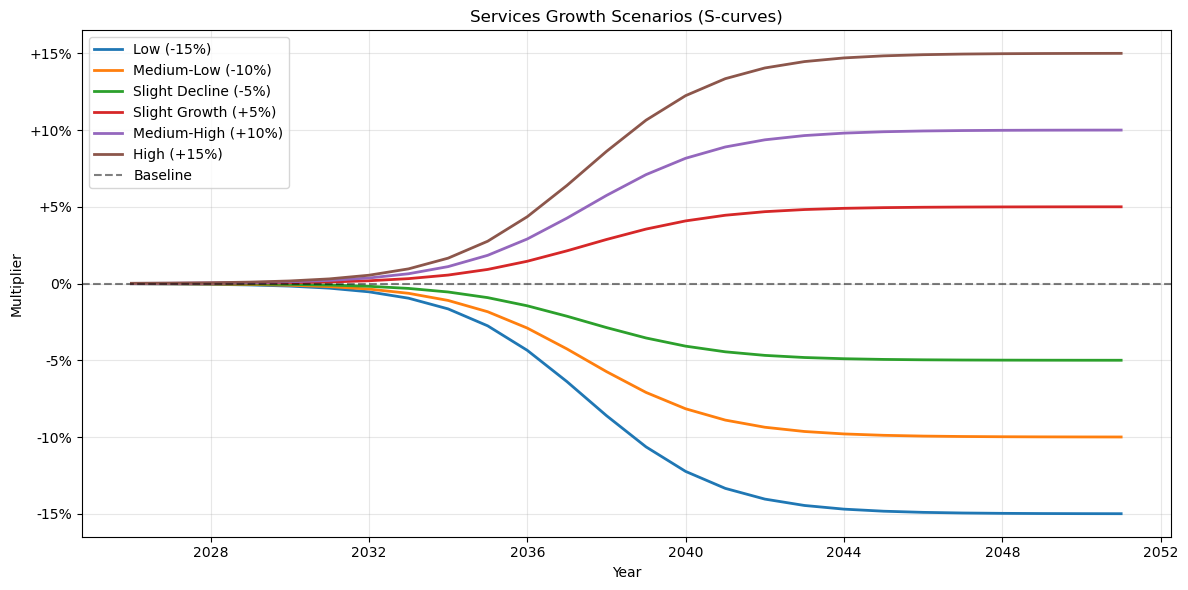

In [4]:
# Visualize the curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Sample to yearly for plotting (too many points otherwise)
for idx, end_mult, label in SCENARIOS:
    subset = result_df[result_df["index"] == idx].copy()
    # Resample to yearly for cleaner plot
    subset = subset.set_index("timestamp").resample("YE").mean().reset_index()
    
    color = "red" if end_mult < 1.0 else "green" if end_mult > 1.0 else "gray"
    ax.plot(subset["timestamp"], subset["value"], label=label, linewidth=2)

# Add baseline reference
ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.5, label="Baseline")

ax.set_xlabel("Year")
ax.set_ylabel("Multiplier")
ax.set_title(f"{SEGMENT.title()} Growth Scenarios (S-curves)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)

# Format y-axis as percentage change
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{(y-1)*100:+.0f}%" if y != 1 else "0%"))

plt.tight_layout()
plt.show()

In [5]:
# Write output
output_path = NOTEBOOK_DIR / "curves.parquet"

result_df.to_parquet(output_path, index=False)

print(f"Written: {output_path}")
print(f"Size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

# Verify
verify_df = pd.read_parquet(output_path)
print(f"\nVerification:")
print(f"  Rows: {len(verify_df):,}")
print(f"  Columns: {list(verify_df.columns)}")
print(f"  Indices: {sorted(verify_df['index'].unique())}")
print(f"  Time range: {verify_df['timestamp'].min()} to {verify_df['timestamp'].max()}")

Written: /home/viktor/code/behovskartan/generator/input/scenarios/services_growth/curves.parquet
Size: 20.05 MB

Verification:
  Rows: 1,367,424
  Columns: ['timestamp', 'index', 'value']
  Indices: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  Time range: 2025-01-01 00:00:00 to 2050-12-31 23:00:00


In [6]:
# Summary table
print(f"\n{'='*60}")
print(f"SUMMARY: {SEGMENT}_growth curves")
print(f"{'='*60}")
print(f"\n{'Index':<8} {'Label':<25} {'Start':<10} {'End':<10} {'Change':<10}")
print("-" * 60)
print(f"{'0':<8} {'Baseline':<25} {'1.0000':<10} {'1.0000':<10} {'0%':<10}")
for idx, end_mult, label in SCENARIOS:
    change = (end_mult - 1) * 100
    print(f"{idx:<8} {label:<25} {'1.0000':<10} {end_mult:<10.4f} {change:+.0f}%")
print(f"\nOutput: {output_path}")


SUMMARY: services_growth curves

Index    Label                     Start      End        Change    
------------------------------------------------------------
0        Baseline                  1.0000     1.0000     0%        
1        Low (-15%)                1.0000     0.8500     -15%
2        Medium-Low (-10%)         1.0000     0.9000     -10%
3        Slight Decline (-5%)      1.0000     0.9500     -5%
4        Slight Growth (+5%)       1.0000     1.0500     +5%
5        Medium-High (+10%)        1.0000     1.1000     +10%
6        High (+15%)               1.0000     1.1500     +15%

Output: /home/viktor/code/behovskartan/generator/input/scenarios/services_growth/curves.parquet
